Importing Libraries

In [95]:
%pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import talib as ta
import plotly.express as px
import sklearn.metrics as classification_report
from xgboost import XGBClassifier

np.random.seed(42)

Note: you may need to restart the kernel to use updated packages.


# Fetch the Data

In [96]:
ticker= 'META'
df = yf.download(ticker,period = '10y',)
df.head()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-02-24,68.739998,71.440002,68.540001,70.779999,70.704979,76620300
2014-02-25,70.949997,71.000000,69.449997,69.849998,69.775963,52077000
2014-02-26,70.190002,71.220001,68.849998,69.260002,69.186592,55322700
2014-02-27,69.339996,70.010002,68.870003,68.940002,68.866936,41653700
2014-02-28,69.470001,69.879997,67.379997,68.459999,68.387436,66783700


In [97]:
data = df.copy()

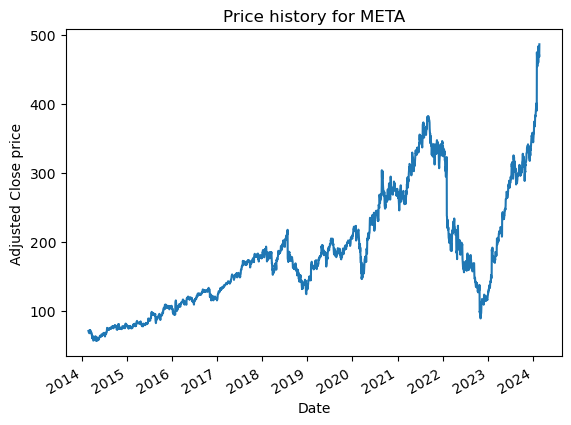

In [98]:
# Plot the adjusted close price
data['Adj Close'].plot()
plt.ylabel('Adjusted Close price')
plt.title(f'Price history for {ticker}')
plt.show()

In [99]:
# Preprocess the data

data['Adj High'] = data['High'] - (data['Adj Close'] - data['Close'])
data['Adj Low'] = data['Low'] + (data['Adj Close'] - data['Close'])

data['Returns'] = data['Adj Close'].pct_change()
data['Target'] = np.where(data['Returns'].shift(-1) > 0, 1, 0)

In [100]:
# Feature Engineering
# arron, z-score, price-trend

data['STD15'] = data['Adj Close'].rolling(window=15).std()
data['MA15'] = data['Adj Close'].rolling(window=15).mean()

data['ARRON'] = ta.AROONOSC(data['Adj High'], data['Adj Low'], timeperiod=14)
data['Z-Score'] = (data['Adj Close'] - data['MA15']) / data['STD15']
data['Price-Trend'] = data['Returns'].shift().rolling(window=4).sum()

data['ARRON'] = pd.qcut(data['ARRON'], q=6, labels=False)
data['Z-Score'] = pd.qcut(data['Z-Score'], q=6, labels=False)
data['Price-Trend'] = pd.qcut(data['Price-Trend'], q=6, labels=False)

data = data.dropna()
features_list = ['ARRON', 'Z-Score', 'Price-Trend']
data[features_list].head()

,ARRON,Z-Score,Price-Trend
Date,,,
2014-03-14,3.0,0.0,1.0
2014-03-17,3.0,1.0,0.0
2014-03-18,3.0,2.0,1.0
2014-03-19,3.0,1.0,1.0
2014-03-20,3.0,0.0,2.0


# Building the Model

In [101]:

import math 
train_end = math.ceil(len(data) * 0.8)  # 80% train, 20% test
train_end_date = data.index[train_end]

X_train,X_test = data[features_list].loc[:train_end_date],data[features_list].loc[train_end_date:]
y_train,y_test = data['Target'].loc[:train_end_date],data['Target'].loc[train_end_date:]

X_train.head()
X_test.head()

,ARRON,Z-Score,Price-Trend
Date,,,
2022-02-25,0.0,1.0,2.0
2022-02-28,0.0,1.0,4.0
2022-03-01,0.0,1.0,5.0
2022-03-02,0.0,1.0,4.0
2022-03-03,0.0,1.0,2.0


In [102]:
model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [103]:
# Evaluate the model
y_pred = model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.40      0.43       239
           1       0.51      0.57      0.54       261

    accuracy                           0.49       500
   macro avg       0.49      0.49      0.49       500
weighted avg       0.49      0.49      0.49       500



# Backtesting the XGBClassifier Model

In [104]:
data['Train_Test'] = np.where(data.index > train_end_date,'Test','Train')

y_pred_all = model.predict(data[features_list])

data['Signal'] = np.where(y_pred_all == 1, 1, -1)

data['Model_Returns'] = data['Target'] * data['Signal']


In [105]:
# Plot the results
fig = px.line(data,x = data.index, y = data['Model_Returns'].cumsum()*100,color= "Train_Test",title = f'Model Returns of {ticker}',
                labels = {'x':'Date','y':'Returns'},template = 'plotly_dark',line_shape='linear',width=1000,height=500)
fig.show()

In [106]:
# calculate yearly rate of return
data_test = data.loc[train_end_date:]
data_test['Year'] = data_test.index.year

# plot the returns by year
returns_by_year = data_test.groupby("Year")["Model_Returns"].sum()*100
px.bar(returns_by_year, labels={"value": "Returns (%)", "Year": "Year"},
       title=f"{model.__class__.__name__} - AAPL - Test Data")

C:\Users\HaikuJAM02102021\AppData\Local\Temp\ipykernel_3640\3515915629.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [107]:
print("Total Return: ", data_test["Model_Returns"].sum()*100)
print("Mean: ", returns_by_year.mean())

Total Return:  3900
Mean:  1300.0
